MuPDF error: format error: No common ancestor in structure tree

MuPDF error: format error: No common ancestor in structure tree

MuPDF error: format error: No common ancestor in structure tree

MuPDF error: format error: No common ancestor in structure tree

MuPDF error: format error: No common ancestor in structure tree

MuPDF error: format error: No common ancestor in structure tree

MuPDF error: format error: No common ancestor in structure tree

MuPDF error: format error: No common ancestor in structure tree

MuPDF error: format error: No common ancestor in structure tree

MuPDF error: format error: No common ancestor in structure tree

Loaded 114 slides
Grayscale best match:   slide 58 (diff=408184)
Normalized best match:  slide 58 (diff=7265.6187)


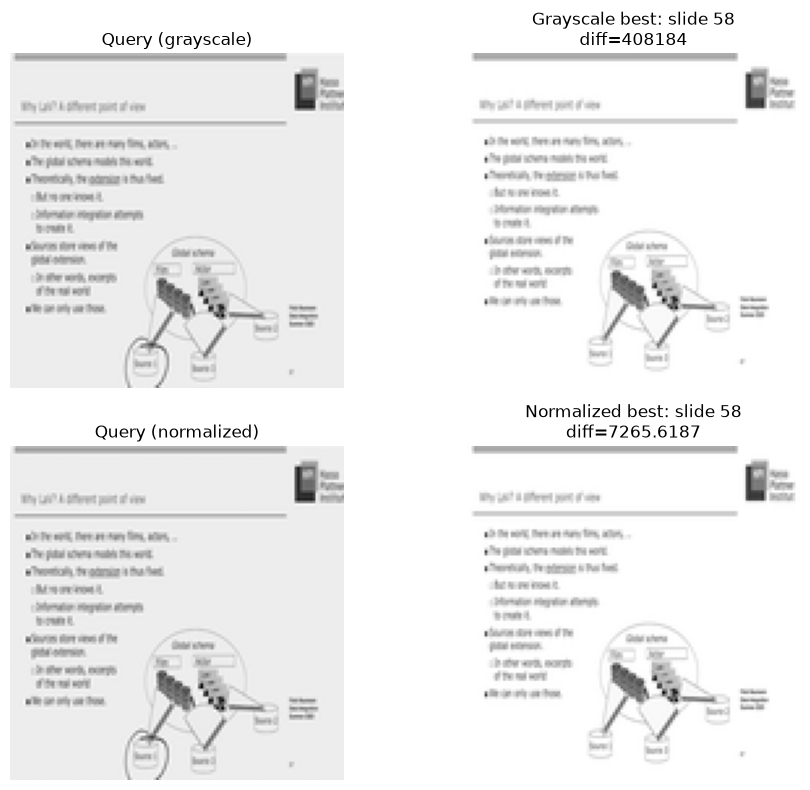


Rank   Grayscale slide       diff    Normalized slide       diff
1                   58     408184                  58  7265.6187
2                   66     412573                  94  7983.4077
3                   29     417685                 109  8047.9409
4                   20     418143                  19  8096.4106
5                   22     419166                  44  8136.8184
6                   94     422845                  74  8140.2266
7                  101     423340                  71  8256.3301
8                  103     423612                 101  8269.4521
9                  109     423734                  85  8286.2031
10                  74     424278                  26  8293.6357
11                  26     424483                  70  8313.9922
12                  28     424977                  68  8314.1367
13                  19     425312                  10  8373.3125
14                  71     426126                  87  8377.3477
15                  44  

In [2]:
import fitz  # pymupdf
import numpy as np
from PIL import Image, ImageOps
import cv2
import matplotlib.pyplot as plt

TARGET_SIZE = (128, 128)

def load_grayscale(img: Image.Image) -> np.ndarray:
    gray = ImageOps.grayscale(img)
    resized = gray.resize(TARGET_SIZE, Image.LANCZOS)
    return np.array(resized, dtype=np.float32)

def normalize(arr: np.ndarray) -> np.ndarray:
    mean, std = arr.mean(), arr.std()
    return (arr - mean) / (std if std > 0 else 1.0)

def load_images(path=None, pdf_path=None):
    """Returns (gray_list, norm_list) for either a single image or all PDF pages."""
    grays, norms = [], []
    if path:
        raw = load_grayscale(Image.open(path))
        grays.append(raw)
        norms.append(normalize(raw))
    if pdf_path:
        pdf = fitz.open(pdf_path)
        for page in pdf:
            pix = page.get_pixmap(dpi=72)
            img = Image.frombytes("RGB", (pix.width, pix.height), pix.samples)
            raw = load_grayscale(img)
            grays.append(raw)
            norms.append(normalize(raw))
        pdf.close()
    return grays, norms

# Load crop
[crop_gray], [crop_norm] = load_images(path="crop_1.png")

# Load slides
slide_grays, slide_norms = load_images(pdf_path="data/query_planning.pdf")
print(f"Loaded {len(slide_grays)} slides")

# --- Grayscale diff ---
diffs_gray = [np.sum(np.abs(crop_gray - s)) for s in slide_grays]
best_gray = int(np.argmin(diffs_gray))

# --- Normalized diff (mean-subtracted, variance-scaled) ---
diffs_norm = [np.sum(np.abs(crop_norm - s)) for s in slide_norms]
best_norm = int(np.argmin(diffs_norm))

print(f"Grayscale best match:   slide {best_gray + 1} (diff={diffs_gray[best_gray]:.0f})")
print(f"Normalized best match:  slide {best_norm + 1} (diff={diffs_norm[best_norm]:.4f})")

# --- Side-by-side comparison ---
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].imshow(crop_gray, cmap="gray", vmin=0, vmax=255)
axes[0, 0].set_title("Query (grayscale)")
axes[0, 0].axis("off")

axes[0, 1].imshow(slide_grays[best_gray], cmap="gray", vmin=0, vmax=255)
axes[0, 1].set_title(f"Grayscale best: slide {best_gray + 1}\ndiff={diffs_gray[best_gray]:.0f}")
axes[0, 1].axis("off")

axes[1, 0].imshow(crop_norm, cmap="gray")
axes[1, 0].set_title("Query (normalized)")
axes[1, 0].axis("off")

axes[1, 1].imshow(slide_norms[best_norm], cmap="gray")
axes[1, 1].set_title(f"Normalized best: slide {best_norm + 1}\ndiff={diffs_norm[best_norm]:.4f}")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

# --- Rankings side by side ---
gray_ranked = sorted(enumerate(diffs_gray), key=lambda x: x[1])
norm_ranked = sorted(enumerate(diffs_norm), key=lambda x: x[1])
print(f"\n{'Rank':<6} {'Grayscale slide':>15} {'diff':>10}    {'Normalized slide':>16} {'diff':>10}")
for rank, ((gi, gd), (ni, nd)) in enumerate(zip(gray_ranked, norm_ranked), 1):
    print(f"{rank:<6} {gi+1:>15} {gd:>10.0f}    {ni+1:>16} {nd:>10.4f}")


In [3]:
def extract_frame(video_path, timestamp):
    cmd = [
        "ffmpeg", "-y",
        "-ss", str(timestamp),
        "-i", str(video_path),
        "-frames:v", "1",
        "-f", "image2pipe",
        "-vcodec", "png",
        "pipe:1",
    ]
    result = subprocess.run(cmd, capture_output=True)
    if result.returncode != 0 or not result.stdout:
        return None
    img = Image.open(io.BytesIO(result.stdout))
    return _to_normalized(img)

In [4]:
import re
from types import SimpleNamespace

_TS_RE = re.compile(r"\[(\d{2}:\d{2}:\d{2}\.\d+) --> (\d{2}:\d{2}:\d{2}\.\d+)\]")

def _ts_to_sec(ts: str) -> float:
    h, m, s = ts.split(":")
    return int(h) * 3600 + int(m) * 60 + float(s)

def extract_timestamps(path):
    segments = []
    current_start = current_end = None
    text_lines = []

    with open(path, "r") as f:
        for line in f:
            line = line.rstrip("\n")
            m = _TS_RE.match(line)
            if m:
                if current_start is not None and text_lines:
                    segments.append(SimpleNamespace(
                        start=current_start,
                        end=current_end,
                        text=" ".join(text_lines),
                    ))
                current_start = _ts_to_sec(m.group(1))
                current_end = _ts_to_sec(m.group(2))
                text_lines = []
            elif line.strip() and current_start is not None:
                text_lines.append(line.strip())

    if current_start is not None and text_lines:
        segments.append(SimpleNamespace(
            start=current_start,
            end=current_end,
            text=" ".join(text_lines),
        ))

    return segments


In [5]:
videoPath = '/Users/jannisarnold/Documents/projekt/videoToTranscript/data/query_planning.mp4'
transcriptPath = '/Users/jannisarnold/Documents/projekt/videoToTranscript/data/query_planning.txt'

In [6]:
seg_list = extract_timestamps(transcriptPath)

In [7]:
_TARGET_SIZE = (128, 128)

import subprocess
import io

def _to_normalized(img):
    gray = ImageOps.grayscale(img)
    resized = gray.resize(_TARGET_SIZE, Image.LANCZOS)
    arr = np.array(resized, dtype=np.float32)
    mean, std = arr.mean(), arr.std()
    return (arr - mean) / (std if std > 0 else 1.0)

def load_pdf_slides(pdf_path):
    slides = []
    pdf = fitz.open(str(pdf_path))
    for page in pdf:
        pix = page.get_pixmap(dpi=72)
        img = Image.frombytes("RGB", (pix.width, pix.height), pix.samples)
        slides.append(_to_normalized(img))
    pdf.close()
    return slides

def extract_frame(video_path, timestamp):
    cmd = [
        "ffmpeg", "-y",
        "-ss", str(timestamp),
        "-i", str(video_path),
        "-frames:v", "1",
        "-f", "image2pipe",
        "-vcodec", "png",
        "pipe:1",
    ]
    result = subprocess.run(cmd, capture_output=True)
    if result.returncode != 0 or not result.stdout:
        return None
    img = Image.open(io.BytesIO(result.stdout))
    return _to_normalized(img)

def _extract_frame_raw(video_path, timestamp):
    cmd = [
        "ffmpeg", "-y",
        "-ss", str(timestamp),
        "-i", str(video_path),
        "-frames:v", "1",
        "-f", "image2pipe",
        "-vcodec", "png",
        "pipe:1",
    ]
    result = subprocess.run(cmd, capture_output=True)
    if result.returncode != 0 or not result.stdout:
        return None

    arr = np.frombuffer(result.stdout, dtype=np.uint8)
    img = cv2.imdecode(arr, cv2.IMREAD_GRAYSCALE)
    resized = cv2.resize(img, _TARGET_SIZE, interpolation=cv2.INTER_LANCZOS4)
    return resized

def best_slide(frame, slides):
    diffs = [np.sum(np.abs(frame - s)) for s in slides]
    return int(np.argmin(diffs)) + 1  # 1-based



In [ ]:


frames = []
for seg in seg_list:
    frame = extract_frame(videoPath, seg.start)
    frames.append(frame)

In [9]:
pdfPath = '/Users/jannisarnold/Documents/projekt/videoToTranscript/data/query_planning.pdf'
slides = load_pdf_slides(pdfPath)

MuPDF error: format error: No common ancestor in structure tree

MuPDF error: format error: No common ancestor in structure tree

MuPDF error: format error: No common ancestor in structure tree

MuPDF error: format error: No common ancestor in structure tree

MuPDF error: format error: No common ancestor in structure tree

MuPDF error: format error: No common ancestor in structure tree

MuPDF error: format error: No common ancestor in structure tree

MuPDF error: format error: No common ancestor in structure tree

MuPDF error: format error: No common ancestor in structure tree

MuPDF error: format error: No common ancestor in structure tree



In [10]:
slides

[array([[1.4167438, 1.4167438, 1.4167438, ..., 1.4167438, 1.4167438,
         1.4167438],
        [1.4167438, 1.4167438, 1.4167438, ..., 1.4167438, 1.4167438,
         1.4167438],
        [1.4167438, 1.4167438, 1.4167438, ..., 1.4167438, 1.4167438,
         1.4167438],
        ...,
        [1.4167438, 1.4167438, 1.4167438, ..., 1.4167438, 1.4167438,
         1.4167438],
        [1.4167438, 1.4167438, 1.4041364, ..., 1.4167438, 1.4167438,
         1.4167438],
        [1.4167438, 1.4167438, 1.4167438, ..., 1.4167438, 1.4167438,
         1.4167438]], shape=(128, 128), dtype=float32),
 array([[ 0.42351916,  0.4436095 , -0.40018427, ...,  0.4436095 ,
          0.4436095 ,  0.4436095 ],
        [ 0.42351916,  0.4436095 , -0.48054558, ...,  0.4436095 ,
          0.4436095 ,  0.4436095 ],
        [ 0.42351916,  0.4436095 , -0.13901001, ...,  0.4436095 ,
          0.4436095 ,  0.4436095 ],
        ...,
        [ 0.4436095 ,  0.4436095 ,  0.4436095 , ...,  0.4436095 ,
          0.4436095 ,  0.44

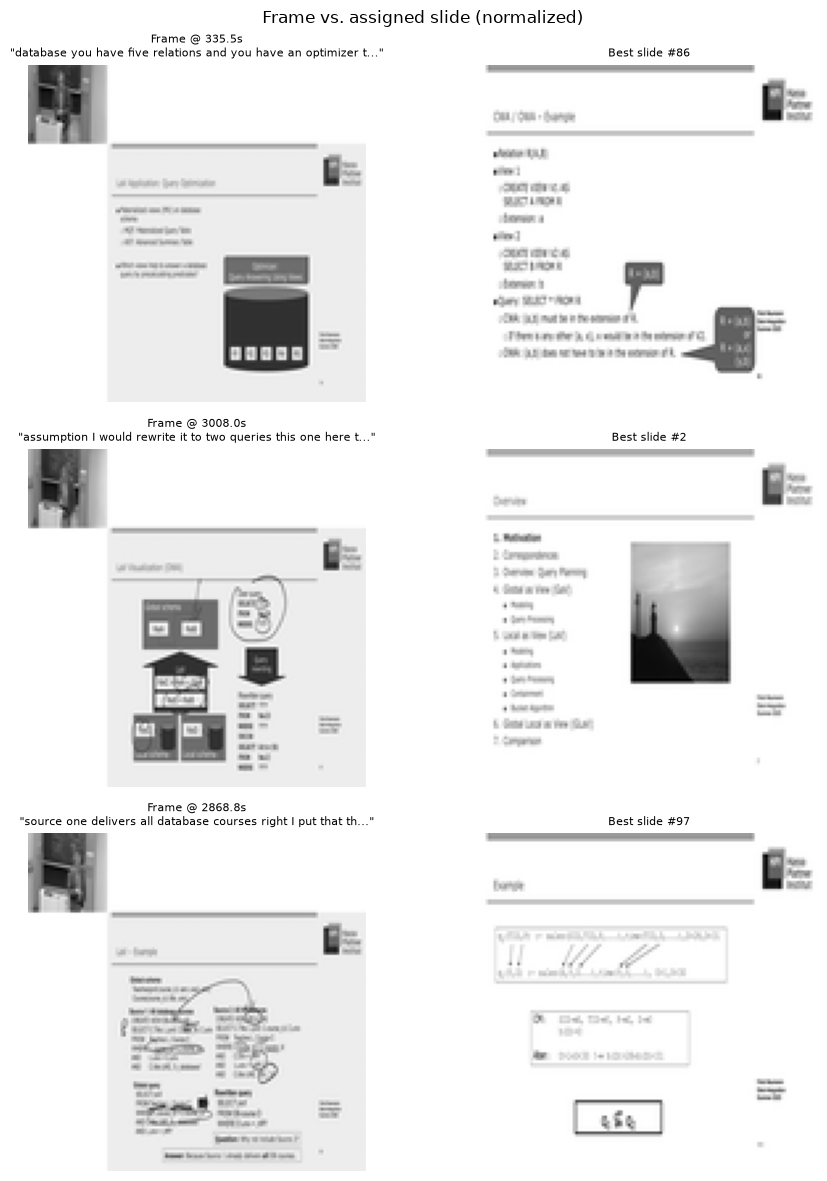

In [11]:
import random

valid = [(i, f) for i, f in enumerate(frames) if f is not None]
picks = random.sample(valid, 3)

fig, axes = plt.subplots(3, 2, figsize=(10, 12))

for row, (i, frame) in enumerate(picks):
    seg = seg_list[i]
    slide_idx = best_slide(frame, slides) - 1  # 0-based

    axes[row, 0].imshow(frame, cmap="gray")
    axes[row, 0].set_title(f"Frame @ {seg.start:.1f}s\n\"{seg.text[:60]}...\"", fontsize=8)
    axes[row, 0].axis("off")

    axes[row, 1].imshow(slides[slide_idx], cmap="gray")
    axes[row, 1].set_title(f"Best slide #{slide_idx + 1}", fontsize=8)
    axes[row, 1].axis("off")

plt.suptitle("Frame vs. assigned slide (normalized)", fontsize=12)
plt.tight_layout()
plt.show()


In [12]:
raw_img = _extract_frame_raw(videoPath, seg_list[3].start)


In [69]:
img = cv2.imread('output.png')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

blur = cv2.GaussianBlur(gray, (5, 5), 0)

sobel_x = cv2.Sobel(blur, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(blur, cv2.CV_64F, 0, 1, ksize=3)
sobel_x2 = cv2.Sobel(np.abs(sobel_x), cv2.CV_64F, 1, 0, ksize=3)
sobel_y2 = cv2.Sobel(np.abs(sobel_y), cv2.CV_64F, 0, 1, ksize=3)

abs_x = cv2.convertScaleAbs(sobel_x + 3 * sobel_x2)
abs_y = cv2.convertScaleAbs(sobel_y + 3 * sobel_y2)

_, binary_x = cv2.threshold(abs_x, 80, 255, cv2.THRESH_BINARY)
_, binary_y = cv2.threshold(abs_y, 80, 255, cv2.THRESH_BINARY)
binary = cv2.bitwise_or(binary_x, binary_y)

# Directional closing: bridge gaps along each axis separately
# Tall thin kernel closes vertical edge gaps; wide flat kernel closes horizontal gaps
k_vert = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 40))
k_horiz = cv2.getStructuringElement(cv2.MORPH_RECT, (40, 1))
closed_v = cv2.morphologyEx(binary_x, cv2.MORPH_CLOSE, k_vert)
closed_h = cv2.morphologyEx(binary_y, cv2.MORPH_CLOSE, k_horiz)
binary_closed = cv2.bitwise_or(closed_v, closed_h)

lines = cv2.HoughLinesP(binary_closed, rho=1, theta=np.pi/180, threshold=40,
                         minLineLength=40, maxLineGap=50)

ANGLE_TOL = 6
h_lines, v_lines = [], []
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        length = np.hypot(x2 - x1, y2 - y1)
        if abs(y2 - y1) <= ANGLE_TOL:
            h_lines.append((length, line[0]))
        elif abs(x2 - x1) <= ANGLE_TOL:
            v_lines.append((length, line[0]))

h_lines.sort(key=lambda t: -t[0])
v_lines.sort(key=lambda t: -t[0])

all_candidates = sorted(h_lines + v_lines, key=lambda t: -t[0])
top2 = [h_lines[0][1], v_lines[0][1]]

print(f"Horizontal candidates: {len(h_lines)}, Vertical candidates: {len(v_lines)}")
for seg in top2:
    x1, y1, x2, y2 = seg
    length = np.hypot(x2 - x1, y2 - y1)
    kind = "H" if abs(y2 - y1) <= ANGLE_TOL else "V"
    print(f"  [{kind}] ({x1},{y1}) -> ({x2},{y2})  length={length:.0f}px")


Horizontal candidates: 330, Vertical candidates: 12
  [H] (0,170) -> (1279,170)  length=1279px
  [V] (296,719) -> (296,0)  length=719px


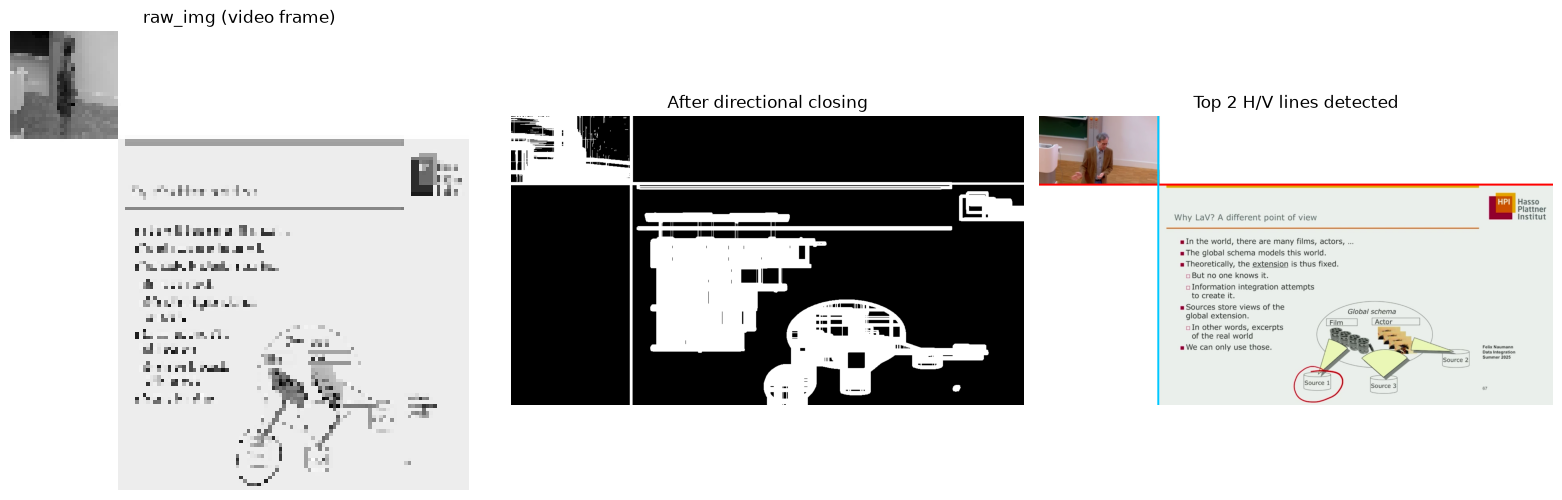

In [70]:
vis = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).copy()
colors = [(255, 0, 0), (0, 200, 255)]
for color, seg in zip(colors, top2):
    x1, y1, x2, y2 = seg
    cv2.line(vis, (x1, y1), (x2, y2), color, 3)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(raw_img, cmap="gray")
axes[0].set_title("raw_img (video frame)")
axes[0].axis("off")

axes[1].imshow(binary_closed, cmap="gray")
axes[1].set_title("After directional closing")
axes[1].axis("off")

axes[2].imshow(vis)
axes[2].set_title("Top 2 H/V lines detected")
axes[2].axis("off")

plt.tight_layout()
plt.show()


In [37]:
def surface_rect(l):
    x1, y1 = l[0][0]
    x2, y2 = l[1][0]
    return abs(x2 - x1) * abs(y2 - y1)
    

In [51]:
def longest_side(l):
    if len(l) != 2: 
        return 0
    else:
        x1, y1 = l[0][0]
        x2, y2 = l[1][0]
        return -max(abs(x2 - x1), abs(y2 - y1))

In [52]:
contendors = sorted(contours, key=longest_side)[:3]

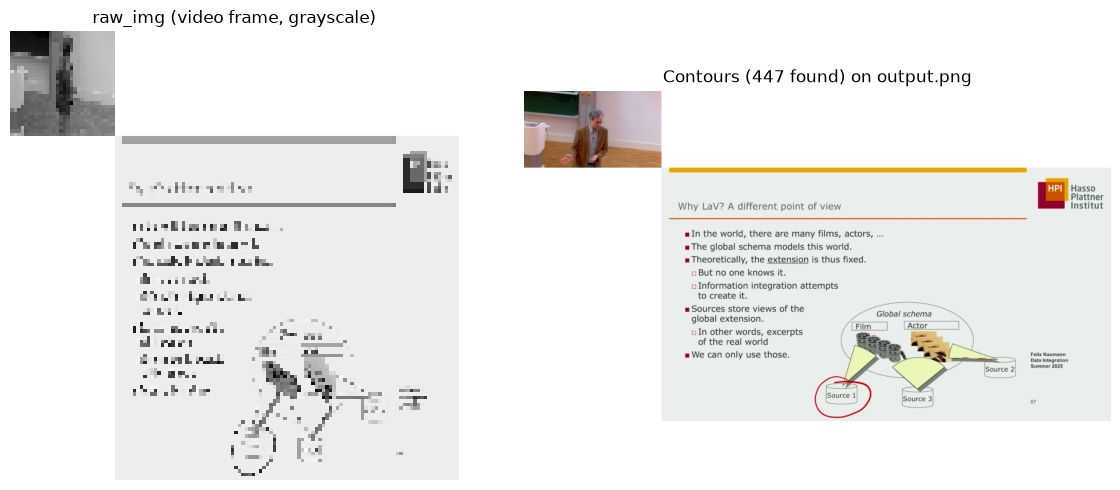

In [53]:
contour_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).copy()
cv2.drawContours(contour_img, contendors, -1, (255, 0, 0), 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(raw_img, cmap="gray")
axes[0].set_title("raw_img (video frame, grayscale)")
axes[0].axis("off")

axes[1].imshow(contour_img)
axes[1].set_title(f"Contours ({len(contours)} found) on output.png")
axes[1].axis("off")

plt.tight_layout()
plt.show()


In [55]:
contendors

[array([[[ 989,  583]],
 
        [[1008,  583]]], dtype=int32),
 array([[[956, 582]],
 
        [[969, 582]]], dtype=int32),
 array([[[758, 534]],
 
        [[767, 534]]], dtype=int32)]

In [71]:
def _extract_frame_bgr(video_path, timestamp):
    """Full-resolution BGR frame — no resize, no normalization."""
    cmd = [
        "ffmpeg", "-y",
        "-ss", str(timestamp),
        "-i", str(video_path),
        "-frames:v", "1",
        "-f", "image2pipe",
        "-vcodec", "png",
        "pipe:1",
    ]
    result = subprocess.run(cmd, capture_output=True)
    if result.returncode != 0 or not result.stdout:
        return None
    arr = np.frombuffer(result.stdout, dtype=np.uint8)
    return cv2.imdecode(arr, cv2.IMREAD_COLOR)


def _find_crop_corner(frame_bgr, ksize=3, threshold=80, angle_tol=6):
    """Return (x_from_vertical_line, y_from_horizontal_line) — used only for cropping."""
    gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    sx  = cv2.Sobel(blur, cv2.CV_64F, 1, 0, ksize=ksize)
    sy  = cv2.Sobel(blur, cv2.CV_64F, 0, 1, ksize=ksize)
    sx2 = cv2.Sobel(np.abs(sx), cv2.CV_64F, 1, 0, ksize=ksize)
    sy2 = cv2.Sobel(np.abs(sy), cv2.CV_64F, 0, 1, ksize=ksize)

    bx = cv2.threshold(cv2.convertScaleAbs(sx + 3 * sx2), threshold, 255, cv2.THRESH_BINARY)[1]
    by = cv2.threshold(cv2.convertScaleAbs(sy + 3 * sy2), threshold, 255, cv2.THRESH_BINARY)[1]

    closed_v = cv2.morphologyEx(bx, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_RECT, (1, 40)))
    closed_h = cv2.morphologyEx(by, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_RECT, (40, 1)))

    lines = cv2.HoughLinesP(cv2.bitwise_or(closed_v, closed_h),
                             rho=1, theta=np.pi/180, threshold=40,
                             minLineLength=40, maxLineGap=50)

    h_lines, v_lines = [], []
    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            length = np.hypot(x2 - x1, y2 - y1)
            if abs(y2 - y1) <= angle_tol:
                h_lines.append((length, line[0]))
            elif abs(x2 - x1) <= angle_tol:
                v_lines.append((length, line[0]))

    h_lines.sort(key=lambda t: -t[0])
    v_lines.sort(key=lambda t: -t[0])

    x_crop = int((v_lines[0][1][0] + v_lines[0][1][2]) / 2) if v_lines else None
    y_crop = int((h_lines[0][1][1] + h_lines[0][1][3]) / 2) if h_lines else None
    return x_crop, y_crop


def crop_and_normalize_frames(video_path, seg_list, n_calibration=10):
    """
    1. Sample n_calibration frames evenly, run edge detection on each to get
       the proposed (x_vertical, y_horizontal) crop corner.
    2. Take the median x and median y across all calibration frames.
    3. Crop every frame to frame[y_crop:h, x_crop:w] (lower-right region).
    4. Normalize each crop with _to_normalized and return the list.
    """
    indices = np.linspace(0, len(seg_list) - 1, n_calibration, dtype=int)

    x_vals, y_vals = [], []
    for i in indices:
        frame_bgr = _extract_frame_bgr(video_path, seg_list[i].start)
        if frame_bgr is None:
            continue
        x, y = _find_crop_corner(frame_bgr)
        if x is not None: x_vals.append(x)
        if y is not None: y_vals.append(y)

    x_crop = int(np.median(x_vals)) if x_vals else 0
    y_crop = int(np.median(y_vals)) if y_vals else 0
    print(f"Crop corner (median of {len(x_vals)} frames): x={x_crop}, y={y_crop}")

    cropped = []
    for seg in seg_list:
        frame_bgr = _extract_frame_bgr(video_path, seg.start)
        if frame_bgr is None:
            cropped.append(None)
            continue
        h, w = frame_bgr.shape[:2]
        roi_pil = Image.fromarray(cv2.cvtColor(frame_bgr[y_crop:h, x_crop:w], cv2.COLOR_BGR2RGB))
        cropped.append(_to_normalized(roi_pil))

    return cropped, (x_crop, y_crop)


In [72]:
cropped_frames, crop_corner = crop_and_normalize_frames(videoPath, seg_list)
print(f"Total frames: {len(cropped_frames)}, successful: {sum(f is not None for f in cropped_frames)}")


Crop corner (median of 10 frames): x=299, y=169
Total frames: 757, successful: 757


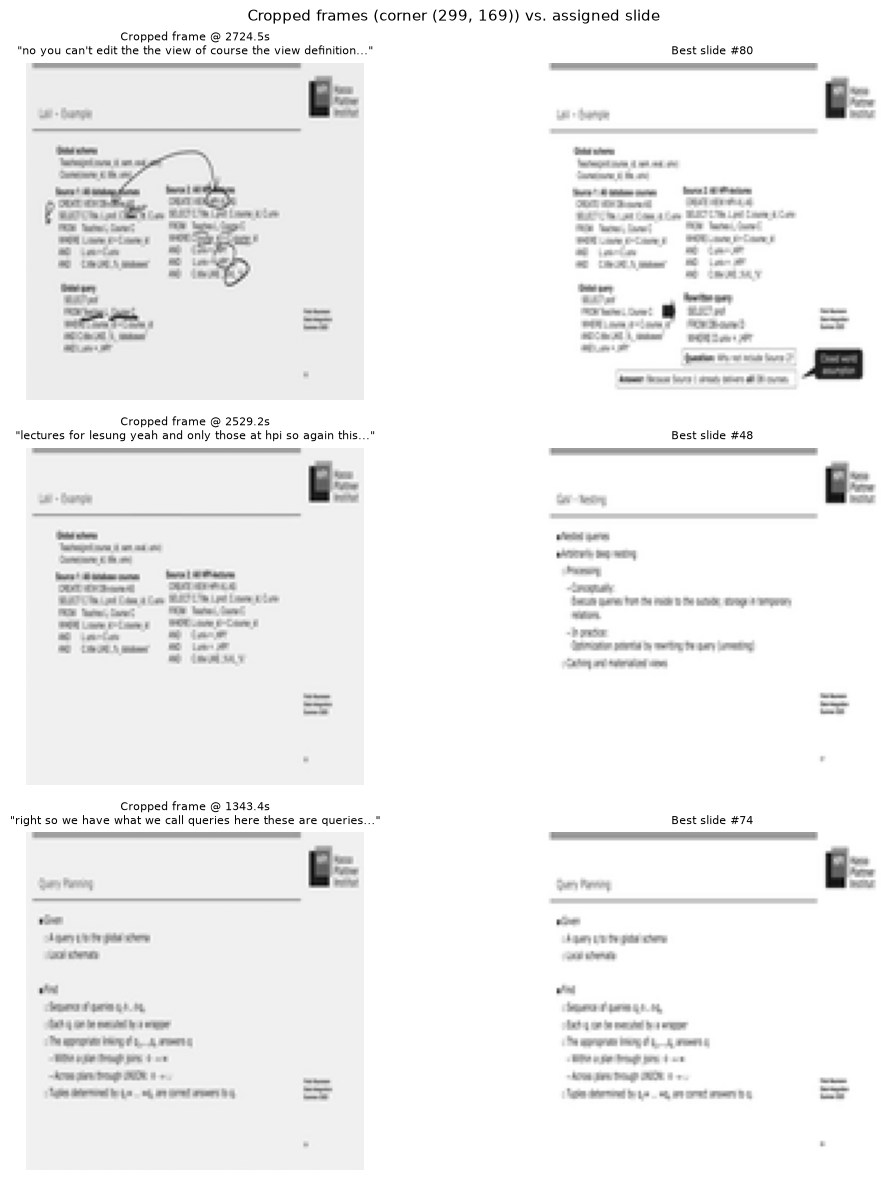

In [73]:
valid_cropped = [(i, f) for i, f in enumerate(cropped_frames) if f is not None]
picks = random.sample(valid_cropped, 3)

fig, axes = plt.subplots(3, 2, figsize=(12, 12))

for row, (i, cropped) in enumerate(picks):
    seg = seg_list[i]
    slide_idx = best_slide(cropped, slides) - 1

    axes[row, 0].imshow(cropped, cmap="gray")
    axes[row, 0].set_title(f"Cropped frame @ {seg.start:.1f}s\n\"{seg.text[:60]}...\"", fontsize=8)
    axes[row, 0].axis("off")

    axes[row, 1].imshow(slides[slide_idx], cmap="gray")
    axes[row, 1].set_title(f"Best slide #{slide_idx + 1}", fontsize=8)
    axes[row, 1].axis("off")

plt.suptitle(f"Cropped frames (corner {crop_corner}) vs. assigned slide", fontsize=11)
plt.tight_layout()
plt.show()
